# Занятие 9. Визуализация данных: Pandas, Matplotlib и Seaborn

> **Цель занятия:** научиться превращать таблицы в графики — строить быстрые
> диаграммы прямо из Pandas методом `.plot()`, понимать устройство графика в
> Matplotlib (полотно `Figure` и оси `Axes`), подписывать заголовки, оси и
> легенду, а также делать разведочные графики в Seaborn: линии трендов,
> столбчатые диаграммы, точечные графики и тепловые карты.

**Что будет:**
1. **Зачем визуализация** — почему график показывает то, что прячут цифры;
2. **Быстрые графики из Pandas** — метод `.plot()`: линия, столбцы, гистограмма, точки;
3. **Устройство графика в Matplotlib** — `Figure` и `Axes`, заголовок, подписи осей, легенда;
4. **Разведочные графики в Seaborn** — зачем он нужен и что автоматизирует; разбивка и
   раскраска по категориям через `hue`: `countplot`, `barplot`, `lineplot`, `histplot`,
   `scatterplot` и тепловые карты `heatmap`.

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')   # убираем технические предупреждения библиотек

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

# единый аккуратный стиль для всех графиков ниже
sns.set_theme(style='whitegrid')

## Загружаем знакомые данные про заказы

Мы продолжаем работать с таблицей заказов онлайн-магазина за 2023–2024 годы —
1500 строк. У каждого заказа есть дата оформления, город, категория товара,
способ оплаты, сумма и число товаров. На прошлом занятии мы уже считали по ней
сводки — теперь научимся эти сводки **рисовать**.

In [216]:
df = pd.read_csv('data/orders.csv', sep=';')
df['created_at'] = pd.to_datetime(df['created_at'])
df['month'] = df['created_at'].dt.month
print('Размер таблицы:', df.shape)
df.head()

Размер таблицы: (1500, 10)


,order_id,created_at,delivered_at,customer_id,city,category,payment,amount,items,month
0,570,2024-02-03 17:52:00,2024-02-05 12:27,1313,Москва,Книги,Карта,2052,2,2
1,431,2024-10-21 03:19:00,2024-10-21 12:27,1356,Москва,Косметика,СБП,2637,3,10
2,80,2024-10-18 02:37:00,2024-10-24 10:32,1050,Самара,Книги,СБП,431,1,10
3,336,2023-10-15 23:52:00,2023-10-19 07:41,1236,Самара,Одежда,Карта,2925,4,10
4,719,2023-06-23 04:37:00,2023-06-26 17:27,1300,Самара,Электроника,Карта,14247,1,6


---
## Часть 1. Зачем визуализация и быстрые графики из Pandas

### 1.1. Почему таблица цифр — это ещё не понимание

Посмотрим на суммарную выручку по месяцам. Это `groupby` с прошлого занятия:

In [217]:
revenue_by_month = df.groupby('month')['amount'].sum()
revenue_by_month

month
1     574766
2     429721
3     529509
4     411273
5     478515
6     517203
7     472133
8     507279
9     651968
10    528349
11    453288
12    526030
Name: amount, dtype: int64

По этому столбцу из 12 чисел трудно сразу сказать, **растёт** ли выручка,
где **пик**, а где **провал**. Глаз считывает форму гораздо быстрее, чем сравнивает
числа в столбик. Именно для этого нужна визуализация: она превращает набор цифр
в **форму**, на которой сразу видны тренды, всплески и выбросы.

### 1.2. Метод `.plot()` — график прямо из Pandas

У любого `Series` и `DataFrame` есть метод **`.plot()`**. Он рисует график по данным
одной строкой — не нужно ничего настраивать вручную. По умолчанию это **линия**:
по оси X — индекс, по оси Y — значения.

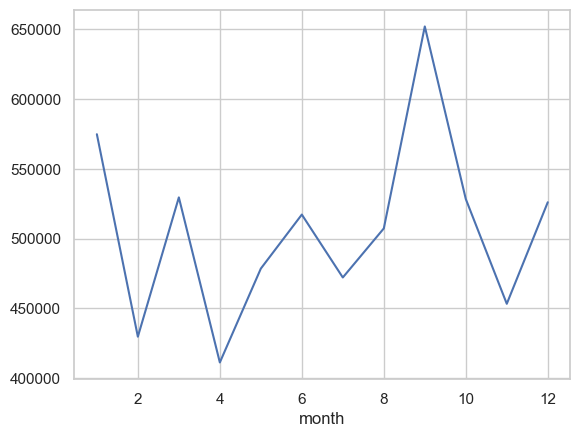

In [218]:
revenue_by_month.plot();

**Вывод:** та же выручка по месяцам, но теперь видно **форму** — в какие месяцы
подъём, в какие спад. Точка с запятой `;` в конце строки убирает служебный технический
текст над графиком — остаётся только сам рисунок.

### 1.3. Выбираем тип графика — параметр `kind`

`.plot()` умеет рисовать не только линию. Тип задаётся параметром **`kind`**.
Для сравнения **категорий** удобнее столбцы — `kind='bar'`. Построим суммарную
выручку по категориям товаров:

In [219]:
revenue_by_category = df.groupby('category')['amount'].sum()
revenue_by_category

category
Дом             610043
Книги           245730
Косметика       427059
Одежда         1446274
Спорт           625723
Электроника    2725205
Name: amount, dtype: int64

Перед графиком всегда полезно взглянуть на саму таблицу — по ней и строим.
Теперь нарисуем её столбцами:

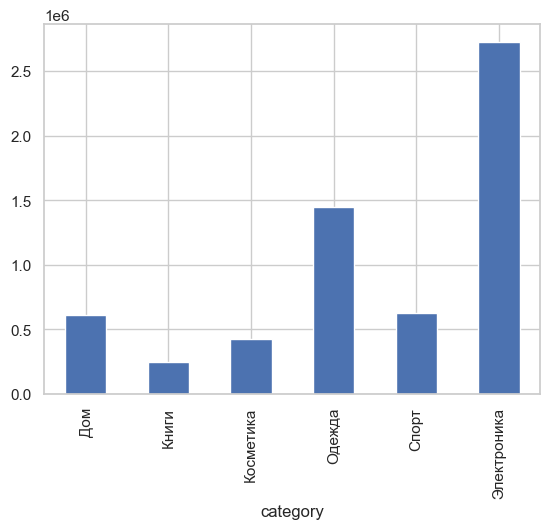

In [220]:
revenue_by_category.plot(kind='bar');

**Вывод:** высота столбца — выручка категории. Сразу видно лидера и аутсайдера —
сравнивать столбики глазу гораздо легче, чем числа.

### 1.4. Частоты через `value_counts()`

Часто нужно посчитать, **сколько раз** встречается каждое значение, и сразу это
нарисовать. Метод `value_counts()` возвращает готовый `Series` — сначала смотрим на него:

In [221]:
city_counts = df['city'].value_counts()
city_counts

city
Москва             523
Санкт-Петербург    315
Казань             138
Новосибирск        123
Екатеринбург       120
Ростов-на-Дону      98
Нижний Новгород     96
Самара              87
Name: count, dtype: int64

Строим по нему столбцы. А если подписей много и по горизонтали они не помещаются —
берём **горизонтальные** столбцы `kind='barh'`:

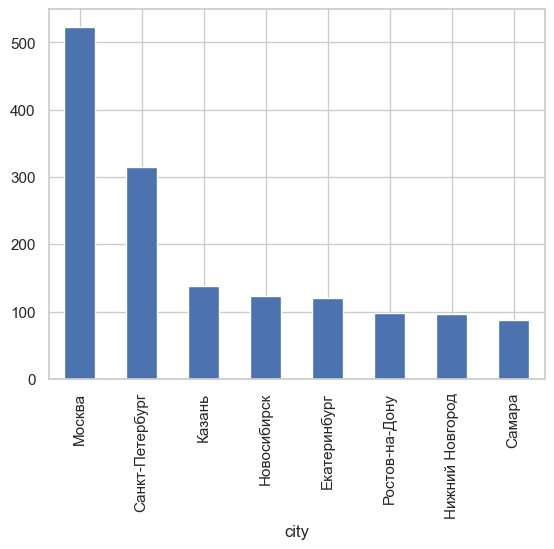

In [222]:
city_counts.plot(kind='bar');

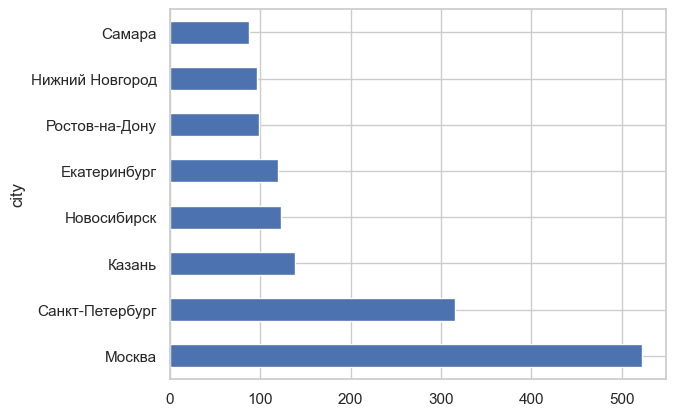

In [223]:
city_counts.plot(kind='barh');

**Вывод:** `bar` — вертикальные столбцы, `barh` — горизонтальные. Для длинных
подписей (города, категории) горизонтальные часто читаются удобнее.

### 1.5. Гистограмма — как устроено распределение

Линия и столбцы сравнивают **готовые** числа. А чтобы понять, **как распределена**
одна величина — например, из каких сумм состоят заказы, — строят **гистограмму**
(`kind='hist'`). Она делит диапазон значений на интервалы (**бины**) и показывает,
сколько значений попало в каждый.

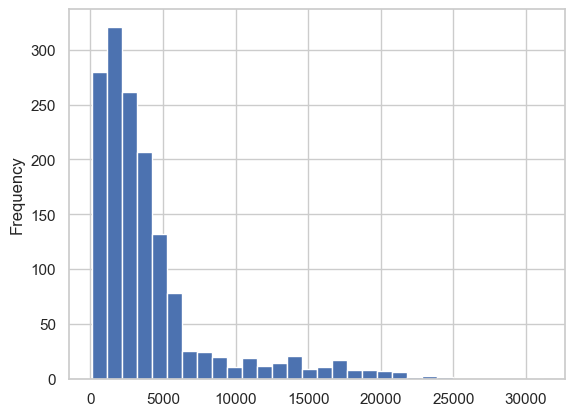

In [224]:
df['amount'].plot(kind='hist', bins=30);

**Вывод:** по оси X — сумма заказа, по оси Y — сколько заказов попало в этот
диапазон. Видно, какие суммы встречаются чаще всего, а какие — редкость. Число
интервалов регулирует `bins`: больше `bins` — детальнее, но «шумнее».

Отдельно стоит запомнить, как гистограмма ведёт себя с **пропусками**. Если в данных
есть `NaN`, они просто **не попадают** ни в один интервал и молча игнорируются — как
и в `.mean()` или `.sum()`. Убирать их вручную перед построением не нужно:

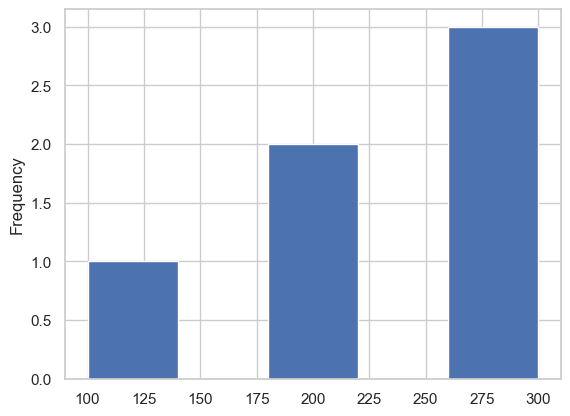

In [225]:
demo = pd.Series([100, 200, 200, np.nan, 300, 300, 300])
demo.plot(kind='hist', bins=5);

**Вывод:** график построился без ошибки — пропуск `NaN` просто выпал из подсчёта,
а остальные значения распределились по интервалам как обычно.

### 1.6. Круговая диаграмма — доли целого

Столбцы сравнивают величины между собой, а **круговая диаграмма** (`kind='pie'`)
показывает, какую **долю от целого** занимает каждая часть. Она уместна, когда части
складываются в осмысленное «100 %» — например, доля выручки по категориям.
`autopct='%1.1f%%'` подписывает проценты прямо на секторах.

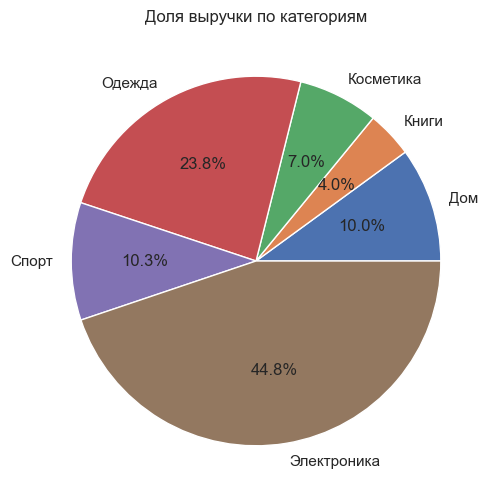

In [226]:
revenue_by_category.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6),
                         ylabel='', title='Доля выручки по категориям');

**Вывод:** размер сектора — доля категории в общей выручке. Круговую берут, когда
частей немного (3–6) и важны именно доли; при большом числе категорий столбцы читаются
лучше.

Круговых удобно строить сразу несколько — чтобы сравнить структуру по разным разрезам.
Посмотрим долю заказов по способам оплаты:

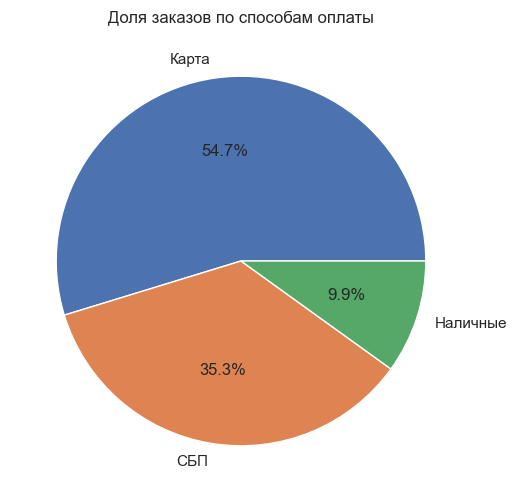

In [227]:
orders_by_payment = df['payment'].value_counts()
orders_by_payment.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6),
                       ylabel='', title='Доля заказов по способам оплаты');

**Вывод:** `value_counts()` дал число заказов по каждому способу оплаты, а
`kind='pie'` показал их долями — сразу видно, чем платят чаще всего.

### 1.7. Точечный график — связь двух величин

Линия, столбцы и гистограмма работают с **одной** величиной. Но часто нужно увидеть
**связь двух** числовых столбцов: растёт ли одно вместе с другим. Для этого есть
**точечный график** (`kind='scatter'`) — каждая точка это одно наблюдение с координатами
(X, Y).

Соберём таблицу по покупателям: сколько заказов сделал каждый и сколько всего потратил.

In [228]:
by_customer = df.groupby('customer_id').agg(
    orders=('order_id', 'count'),
    total=('amount', 'sum'),
    city=('city', 'first'),
)
by_customer.head()

,orders,total,city
customer_id,,,
1000,5,15951,Ростов-на-Дону
1001,4,15864,Москва
1002,1,2863,Санкт-Петербург
1003,2,3807,Москва
1004,4,15497,Москва


Теперь построим точечный график: по X — число заказов, по Y — суммарные траты.
У `kind='scatter'` нужно явно указать, какие столбцы идут на оси.

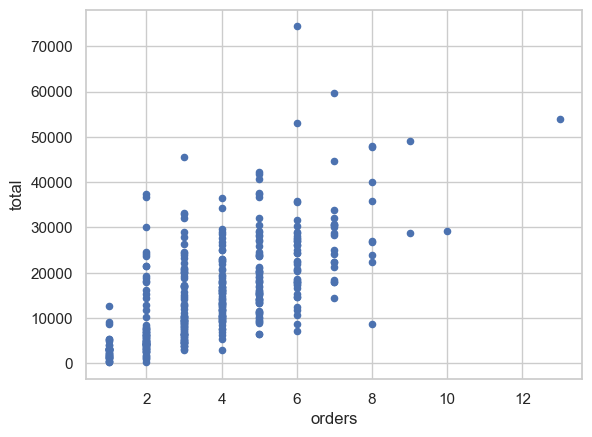

In [229]:
by_customer.plot(kind='scatter', x='orders', y='total');

**Вывод:** облако точек вытянуто вверх-вправо — чем больше заказов делает
покупатель, тем больше он в сумме тратит. Точечный график — главный инструмент, чтобы
на глаз оценить **связь** двух величин.

### 1.8. Составные столбцы — из чего складывается целое

Обычный столбец показывает одну величину на категорию. Но часто интересно, **из чего**
она складывается. Тогда берут **составной (stacked) столбец**: внутри одного столбца
разными цветами показаны части. Соберём таблицу «город × способ оплаты» через `crosstab`
(с прошлого занятия) и посмотрим на неё:

In [230]:
pay_by_city = pd.crosstab(df['city'], df['payment'])
pay_by_city

payment,Карта,Наличные,СБП
city,,,
Екатеринбург,71,10,39
Казань,69,13,56
Москва,276,57,190
Нижний Новгород,56,10,30
Новосибирск,60,15,48
Ростов-на-Дону,56,5,37
Самара,46,7,34
Санкт-Петербург,187,32,96


Каждая строка — город, столбцы — способы оплаты. Нарисуем её составными столбцами
(`stacked=True`):

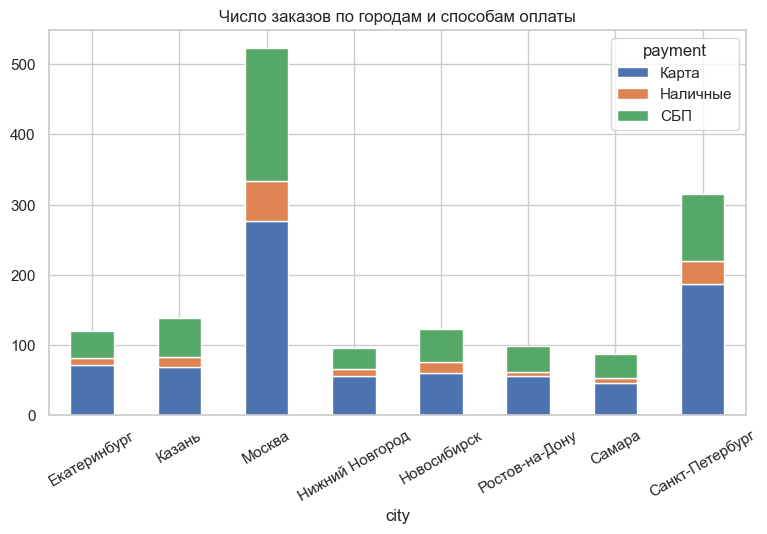

In [231]:
pay_by_city.plot(kind='bar', stacked=True, rot=30, figsize=(9, 5),
                 title='Число заказов по городам и способам оплаты');

**Вывод:** высота всего столбца — число заказов в городе, а цветные части —
сколько пришлось на каждый способ оплаты. Составной столбец показывает одновременно
и общий итог, и его структуру.

**Основные значения `kind`:**

| `kind` | Что рисует | Когда нужен |
|---|---|---|
| `'line'` | линия (по умолчанию) | динамика во времени, тренд |
| `'bar'` / `'barh'` | вертикальные / горизонтальные столбцы | сравнение категорий |
| `'hist'` | гистограмма | распределение одной величины |
| `'scatter'` | точки | связь двух числовых столбцов |
| `'pie'` | круговая | доли целого |

---
## Часть 2. Устройство графика в Matplotlib: `Figure` и `Axes`

Под `.plot()` из Pandas работает библиотека **Matplotlib**. Если понять её устройство,
графиком можно управлять полностью — задавать заголовок, подписи осей, рисовать
несколько линий сразу.

### 2.1. Два объекта: полотно и график

Любой график в Matplotlib — это два вложенных объекта:

- **`Figure`** — картинка целиком, как лист бумаги.
- **`Axes`** — сам график на этом листе: оси X и Y, линии, заголовок.

```
┌────────────────────────────────┐
│ Figure — лист бумаги           │
│   ┌───────────────────────┐    │
│   │ Axes — сам график     │    │
│   │  оси, линии, заголовок│    │
│   └───────────────────────┘    │
└────────────────────────────────┘
```

Оба сразу создаёт команда **`plt.subplots()`** — она возвращает `Figure` (`fig`) и
`Axes` (`ax`). Рисуем и подписываем мы через `ax`.

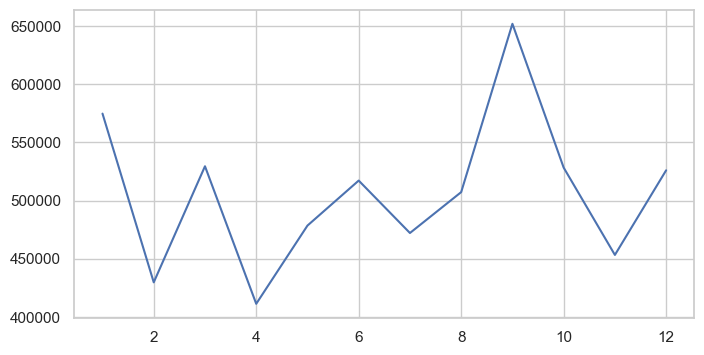

In [232]:
fig, ax = plt.subplots(figsize=(8, 4))   # figsize — размер полотна в дюймах
ax.plot(revenue_by_month.index, revenue_by_month.values);

**Вывод:** `fig` — лист, `ax` — график на нём. Рисуем методом `ax.plot(x, y)`:
первый аргумент по оси X, второй по оси Y. `figsize` — размер картинки в дюймах.

### 2.2. Подписываем график

Оформление задаётся методами объекта `ax`:

- `ax.set_title(...)` — заголовок;
- `ax.set_xlabel(...)` / `ax.set_ylabel(...)` — подписи осей X и Y;
- `ax.legend()` — легенда (имя линии берётся из `label`).

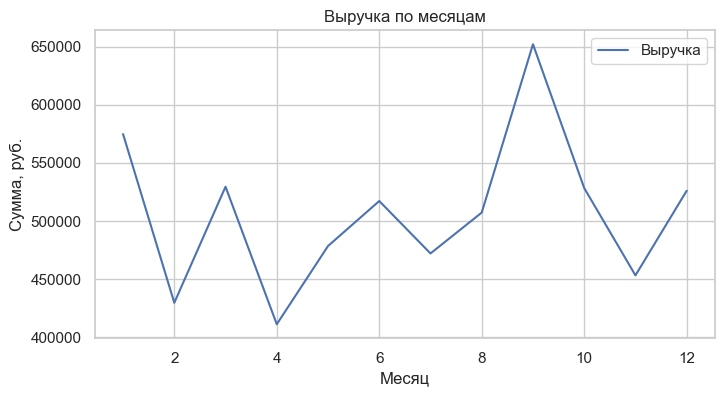

In [233]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(revenue_by_month.index, revenue_by_month.values, label='Выручка')
ax.set_title('Выручка по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Сумма, руб.')
ax.legend();

**Вывод:** график читается сам по себе — заголовок, обе оси и легенда на месте.
Это минимум для графика, который показывают другим.

### 2.3. Несколько линий на одних осях

Ради этого и берут `ax` напрямую: чтобы сравнить несколько рядов на одном графике,
вызываем `ax.plot(...)` несколько раз — каждую линию со своим `label`. Сравним выручку
трёх категорий по месяцам.

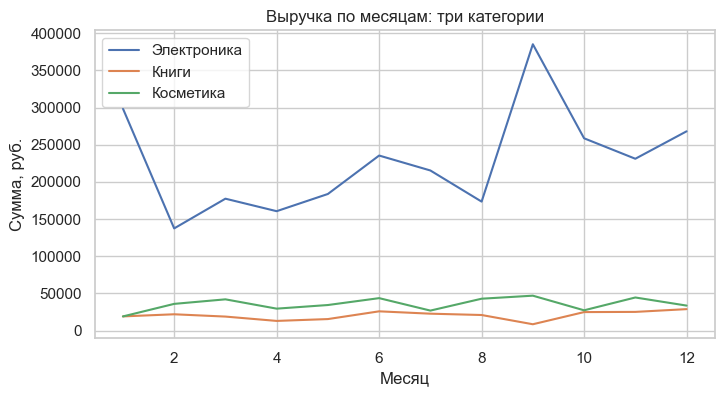

In [234]:
elec = df[df['category'] == 'Электроника'].groupby('month')['amount'].sum()
books = df[df['category'] == 'Книги'].groupby('month')['amount'].sum()
cosm = df[df['category'] == 'Косметика'].groupby('month')['amount'].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(elec.index, elec.values, label='Электроника')
ax.plot(books.index, books.values, label='Книги')
ax.plot(cosm.index, cosm.values, label='Косметика')
ax.set_title('Выручка по месяцам: три категории')
ax.set_xlabel('Месяц')
ax.set_ylabel('Сумма, руб.')
ax.legend();

**Вывод:** каждая линия — отдельный `ax.plot(...)` со своим `label`; оси, заголовок
и легенда общие. Здесь пришлось вручную сделать три фильтра и три `groupby` — дальше
Seaborn проделает это одной строкой.

### 2.4. Несколько графиков на одном полотне

`plt.subplots(2, 2)` создаёт полотно с **сеткой** осей — четыре `Axes` в переменной
`axes`. К каждому обращаемся по индексу `[строка, столбец]` и передаём его в `.plot()`
через `ax=`. Так на одной картинке уместятся сразу четыре разных графика.

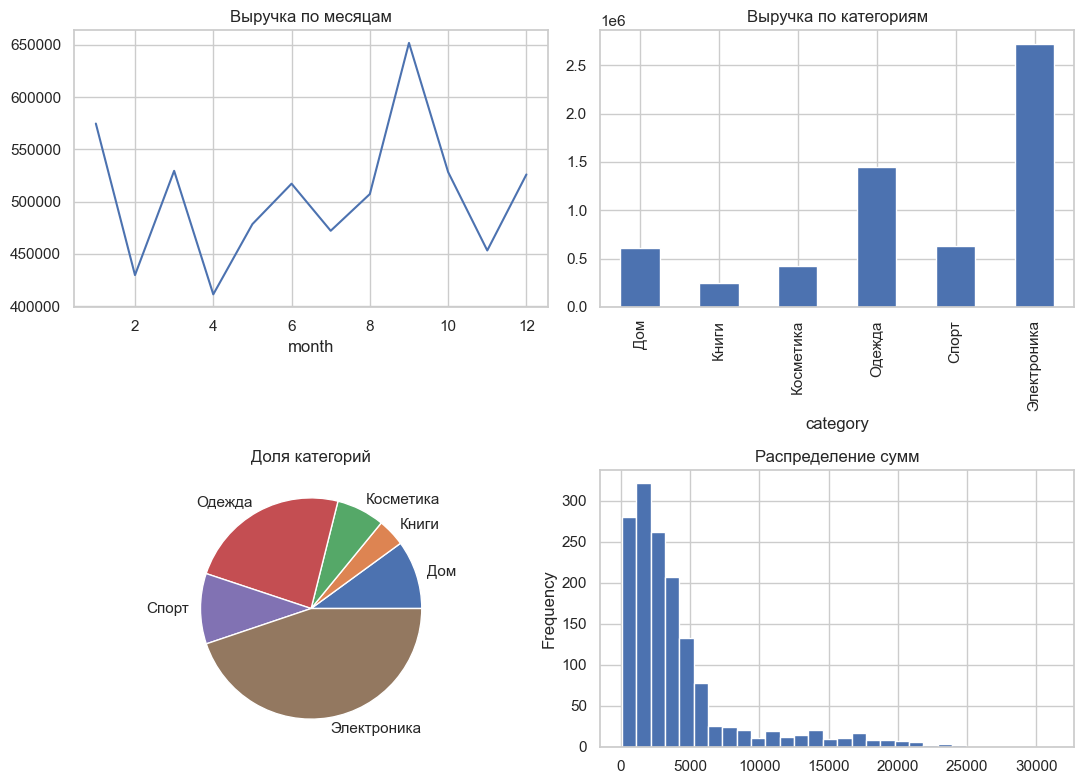

In [235]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

revenue_by_month.plot(ax=axes[0, 0], title='Выручка по месяцам')
revenue_by_category.plot(kind='bar', ax=axes[0, 1], title='Выручка по категориям')
revenue_by_category.plot(kind='pie', ax=axes[1, 0], ylabel='', title='Доля категорий')
df['amount'].plot(kind='hist', bins=30, ax=axes[1, 1], title='Распределение сумм')

plt.tight_layout();

**Вывод:** `axes[0, 0]` — левый верхний график, `axes[1, 1]` — правый нижний.
Каждому передали свой `ax=`, и четыре графика встали в одну сетку. `plt.tight_layout()`
расставляет их так, чтобы подписи не наезжали друг на друга.

---
## Часть 3. Разведочные графики в Seaborn

### 3.1. Зачем нужен Seaborn

**Seaborn** — надстройка над Matplotlib, заточенная под **разведочный анализ**
(*exploratory plotting*): быстро посмотреть на сырые данные и увидеть закономерность.
Он не заменяет Matplotlib, а берёт на себя рутину. Что именно он **автоматизирует**:

- **Работает прямо с `DataFrame`.** Не нужно вытаскивать массивы — указываем имена
  столбцов через `data=`, `x=`, `y=`.
- **Сам агрегирует данные.** `barplot` сам считает среднее по категории, `countplot` —
  частоты, `lineplot` — среднее по каждой точке X. Ручной `groupby` часто не нужен.
- **Сам разбивает по категориям через `hue`.** Три линии из части 2 (три фильтра и три
  `groupby`) Seaborn рисует одной строкой — достаточно указать `hue='category'`.
- **Красиво по умолчанию.** Согласованные цвета, доверительные интервалы, легенда —
  всё «из коробки», без ручной настройки.

Пройдём по основным типам графиков Seaborn на наших заказах.

### 3.2. `countplot` — сам считает частоты категорий

`sns.countplot()` считает, **сколько раз** встречается каждое значение категории —
без всякого `value_counts()` или `groupby`. Просто указываем столбец.

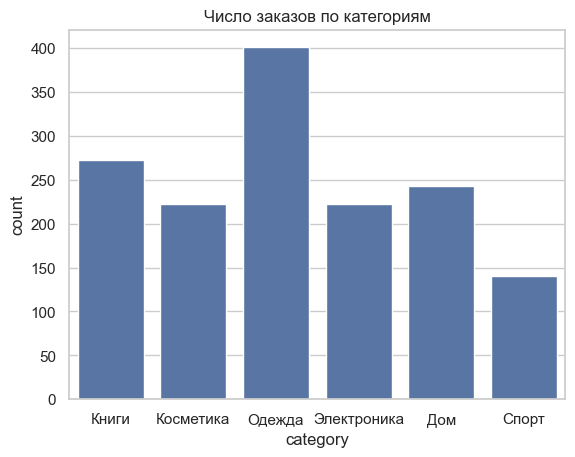

In [236]:
sns.countplot(data=df, x='category')
plt.title('Число заказов по категориям');

**Вывод:** высота столбца — число заказов в категории. Мы не считали частоты
руками — `countplot` сделал это сам прямо из сырой таблицы.

Если подписи категорий длинные, удобнее **горизонтальный** `countplot` — переносим
столбец из `x=` в `y=`:

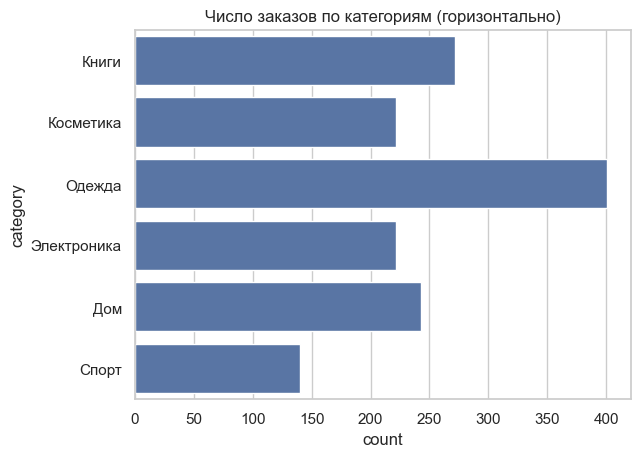

In [237]:
sns.countplot(data=df, y='category')
plt.title('Число заказов по категориям (горизонтально)');

**Вывод:** `x=` даёт вертикальные столбцы, `y=` — горизонтальные. Смысл тот же,
меняется только ориентация — для длинных названий читается легче.

### 3.3. `countplot` с `hue` — разбивка и раскраска по категории

Главная сила Seaborn — **разбивка по второй категории** через параметр `hue`. Добавим
`hue='payment'`: тот же счёт заказов по городам, но каждый столбец разбит по способу
оплаты и раскрашен цветом.

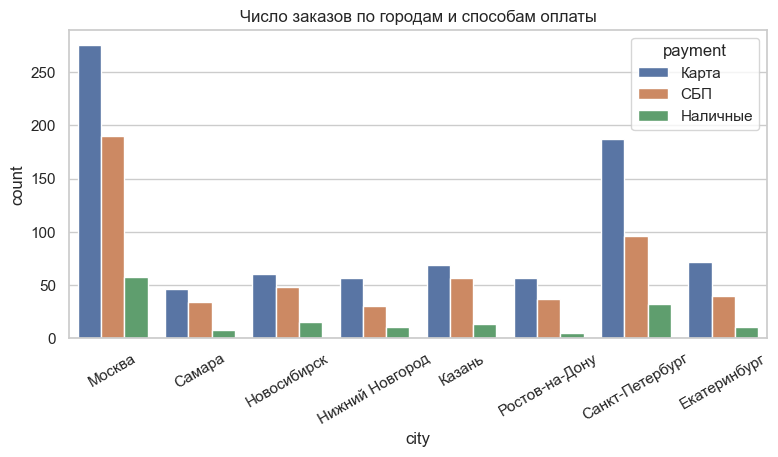

In [238]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='city', hue='payment')
plt.title('Число заказов по городам и способам оплаты')
plt.xticks(rotation=30);

**Вывод:** внутри каждого города столбцы разбились по способу оплаты, цвет и
легенда появились сами. Один параметр `hue` — и вместо одного числа на город виден
его состав по оплате.

### 3.4. `barplot` — сам считает среднее по категории

`sns.barplot()` сравнивает категории столбцами и по умолчанию считает **среднее**
значения `y` в каждой категории `x`. У городов длинные названия — чтобы подписи не
наезжали друг на друга, повернём их через `plt.xticks(rotation=30)`.

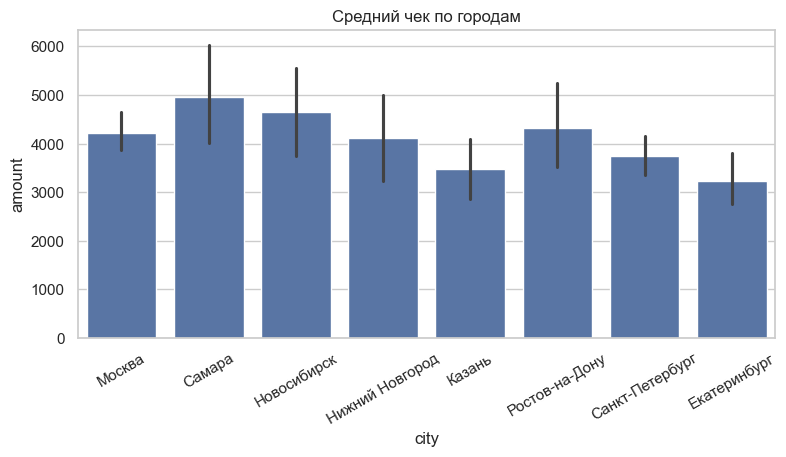

In [239]:
plt.figure(figsize=(9, 4))
sns.barplot(data=df, x='city', y='amount')
plt.title('Средний чек по городам')
plt.xticks(rotation=30);

**Вывод:** высота столбца — средний чек в городе, тонкая чёрточка сверху —
доверительный интервал (насколько уверенно оценено среднее). `groupby` мы не делали —
Seaborn посчитал средние сам. Поворот подписей через `plt.xticks(rotation=30)` решает
проблему налезающих друг на друга названий.

### 3.5. `barplot` с `hue` — средние по двум категориям

`hue` работает и здесь: сравним средний чек по категориям, разбив каждую по способу
оплаты. Столбцы встанут группами, цвет — способ оплаты.

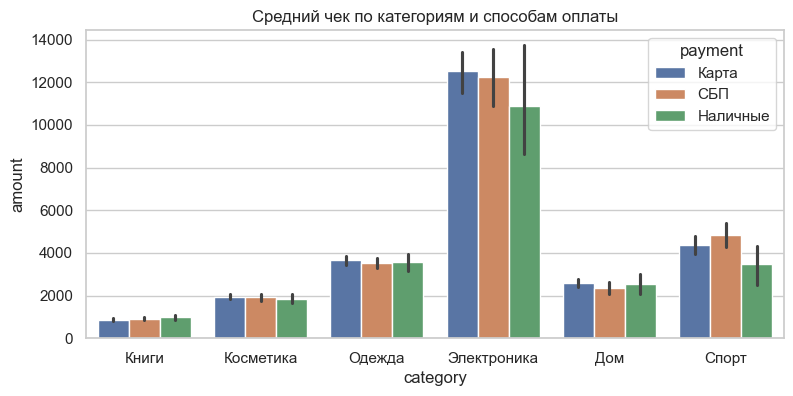

In [240]:
plt.figure(figsize=(9, 4))
sns.barplot(data=df, x='category', y='amount', hue='payment')
plt.title('Средний чек по категориям и способам оплаты');

**Вывод:** каждая категория теперь представлена группой столбцов — по одному на
способ оплаты. Seaborn сам посчитал средние в каждом сочетании и раскрасил их. Так видно
не только уровень по категории, но и различия внутри неё.

### 3.6. `lineplot` — тренд и разбивка через `hue`

`sns.lineplot()` строит линию тренда прямо по таблице и **сам усредняет** значения
`y` в каждой точке `x`. А главное — параметр **`hue`** рисует **отдельную линию на
каждую категорию** автоматически. Вспомните три ручных `groupby` из части 2 — вот их
короткая замена:

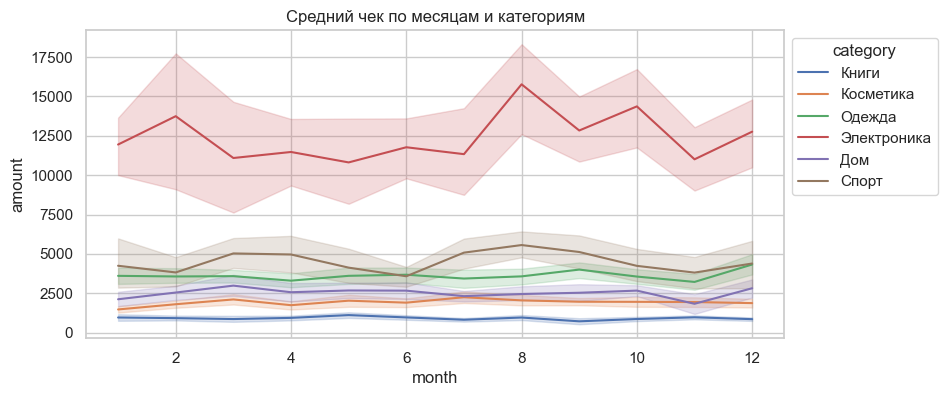

In [241]:
plt.figure(figsize=(9, 4))
sns.lineplot(data=df, x='month', y='amount', hue='category')
plt.title('Средний чек по месяцам и категориям')
sns.move_legend(plt.gca(), 'upper left', bbox_to_anchor=(1, 1));

**Вывод:** одна строка с `hue='category'` заменила три фильтра, три `groupby` и три
вызова `ax.plot` — Seaborn сам разбил данные по категориям, усреднил и подписал линии
легендой. Это и есть та рутина, которую он снимает.

### 3.7. `histplot` — распределение с оценкой плотности

Гистограмму мы уже строили в Pandas. `sns.histplot()` делает то же, но аккуратнее и с
дополнением `kde=True` — сглаженной **кривой плотности** поверх столбцов, которая
подчёркивает форму распределения.

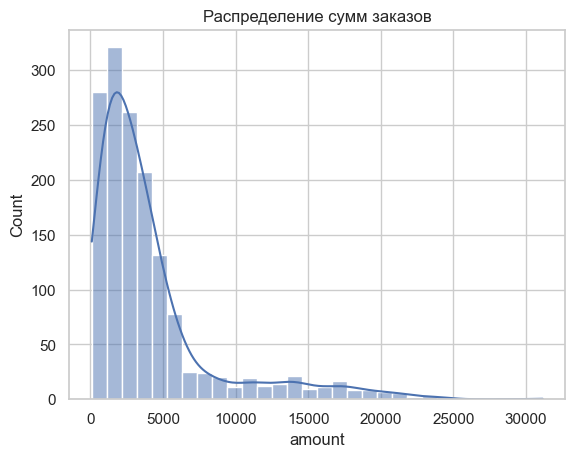

In [242]:
sns.histplot(data=df, x='amount', bins=30, kde=True)
plt.title('Распределение сумм заказов');

**Вывод:** те же интервалы, что и в Pandas-гистограмме, но плавная линия `kde`
показывает форму распределения — где сгущение заказов, а где длинный хвост дорогих
покупок.

### 3.8. `scatterplot` — связь двух величин

Точечный график мы строили в Pandas. `sns.scatterplot()` делает то же прямо из
`DataFrame` и аккуратнее оформляет результат. Возьмём таблицу по покупателям, посмотрим
на связь числа заказов и суммарных трат и добавим поверх **регрессионную прямую** —
`sns.regplot()` с `scatter=False` рисует только линию тренда, без своих точек.

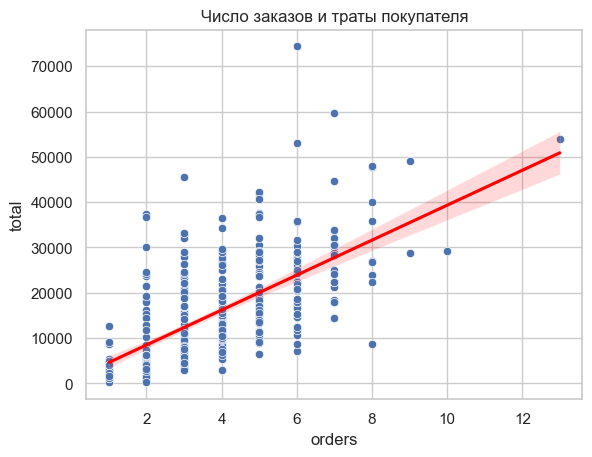

In [249]:
sns.scatterplot(data=by_customer, x='orders', y='total')
sns.regplot(data=by_customer, x='orders', y='total', scatter=False, color='red')
plt.title('Число заказов и траты покупателя');

**Вывод:** облако точек уверенно вытянуто вверх-вправо — чем больше заказов делает
покупатель, тем больше он тратит суммарно. Красная **регрессионная прямая** (её добавил
`sns.regplot(..., scatter=False)`) обобщает эту связь одной линией — по её наклону сразу
видно направление и силу зависимости.

### 3.9. `heatmap` — тепловая карта для таблицы-матрицы

Когда данные — это **двумерная таблица чисел** (строки × столбцы), её удобно показать
**тепловой картой**: каждая клетка красится в цвет по своему значению — яркое выделяет
максимумы. Это идеальная пара к `pivot_table` с прошлого занятия.

Соберём сводную «город × категория» со средним чеком:

In [244]:
pivot_mean = pd.pivot_table(
    df,
    values='amount',
    index='city',
    columns='category',
    aggfunc='mean',
).round()
pivot_mean

category,Дом,Книги,Косметика,Одежда,Спорт,Электроника
city,,,,,,
Екатеринбург,2967.0,852.0,1742.0,3633.0,4397.0,10747.0
Казань,2344.0,907.0,1876.0,3964.0,4279.0,12140.0
Москва,2415.0,937.0,2045.0,3640.0,4372.0,11991.0
Нижний Новгород,2794.0,800.0,2002.0,3768.0,4015.0,13492.0
Новосибирск,1834.0,912.0,1588.0,3402.0,5014.0,13299.0
Ростов-на-Дону,2728.0,828.0,1696.0,3263.0,4537.0,13286.0
Самара,2331.0,736.0,2121.0,3616.0,5075.0,13720.0
Санкт-Петербург,2769.0,935.0,1919.0,3535.0,4686.0,11248.0


Передаём эту матрицу в `sns.heatmap()`. Параметр `annot=True` впишет в клетки сами
числа, `fmt='g'` — покажет их без научной записи, `cmap` задаёт цветовую гамму.

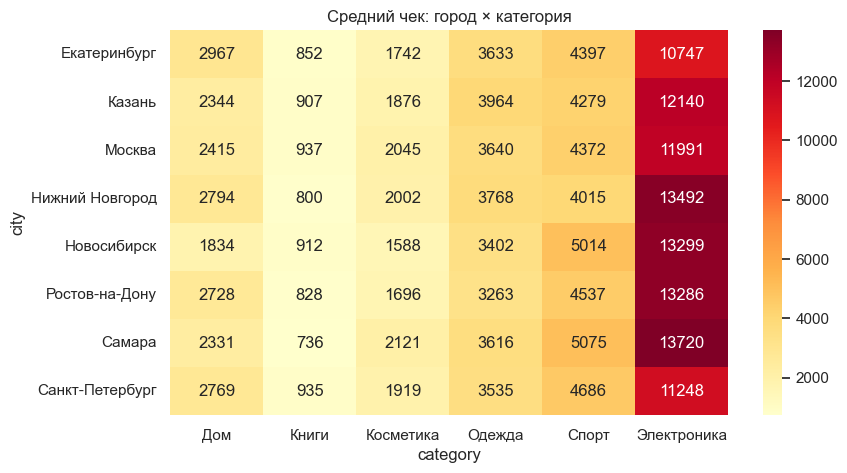

In [245]:
plt.figure(figsize=(9, 5))
sns.heatmap(pivot_mean, annot=True, fmt='g', cmap='YlOrRd')
plt.title('Средний чек: город × категория');

**Вывод:** взгляд мгновенно находит самые «горячие» клетки — сочетания города и
категории с самым высоким средним чеком, — не вчитываясь в числа. Для табличных матриц
это самый наглядный формат.

Тепловая карта работает с **любой** числовой матрицей. Чтобы показать не средний чек,
а **число заказов**, меняем только сводную — `values='order_id'` и `aggfunc='count'`,
а сам вызов `heatmap` остаётся тем же:

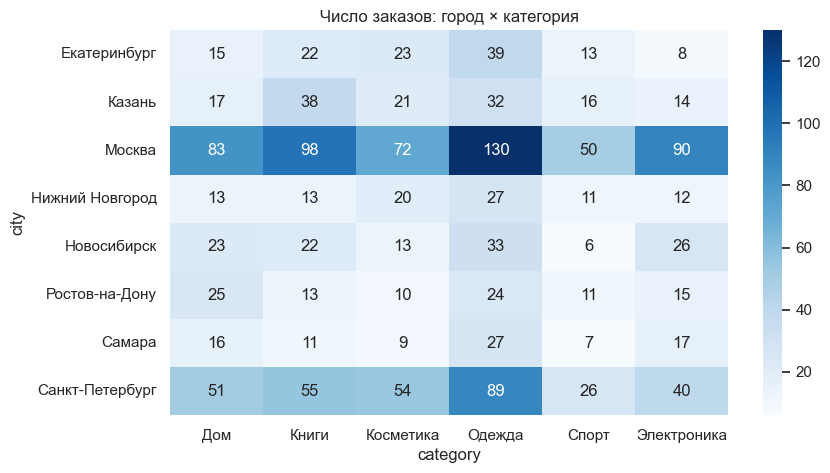

In [246]:
pivot_count = pd.pivot_table(
    df,
    values='order_id',
    index='city',
    columns='category',
    aggfunc='count',
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_count, annot=True, fmt='g', cmap='Blues')
plt.title('Число заказов: город × категория');

**Вывод:** та же тепловая карта, но по частотам заказов. Меняется только исходная
матрица — построение остаётся одинаковым.

### 3.10. Когда что использовать?

| Инструмент | Когда удобно |
|---|---|
| **Pandas `.plot()`** | Быстрый черновой график прямо из `Series` / `DataFrame`, «для себя». |
| **Matplotlib (`fig, ax`)** | Нужен полный контроль: заголовок, подписи осей, несколько линий, легенда. |
| **Seaborn** | Разведочный анализ: авто-агрегация, разбивка по категориям через `hue`, красивые графики одной строкой. |

---
## Итог занятия

Сегодня научились:
- понимать, **зачем** нужна визуализация — график считывается быстрее таблицы цифр
  и показывает тренды, пики, распределение и связи;
- строить **быстрые графики из Pandas** методом **`.plot()`** и выбирать тип через
  `kind` — линия (`'line'`), столбцы (`'bar'`, в т. ч. составные `stacked=True`),
  гистограмма (`'hist'`), круговая (`'pie'`), точки (`'scatter'`);
- понимать устройство графика в **Matplotlib**: полотно **`Figure`** и область
  графика **`Axes`**, создавать их через **`plt.subplots()`**, подписывать через
  `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()`, `ax.legend()` и рисовать
  несколько линий на одних осях;
- делать **разведочные графики в Seaborn** прямо из таблицы с разбивкой и раскраской
  по категориям через **`hue`**: **`countplot`**, **`barplot`**, **`lineplot`**,
  **`histplot`**, **`scatterplot`** и тепловые карты **`heatmap`**.

**Главная мысль:** визуализация — это не украшение, а **инструмент анализа**.
Pandas `.plot()` нужен для быстрого взгляда, Matplotlib — для точного контроля и
подписей, а Seaborn берёт на себя рутину (агрегацию, разбивку по категориям, оформление)
и позволяет увидеть закономерность в сырых данных одной строкой.